# Overview

**Single-Agent Fusion (Vision) Pipeline**

This notebook implements the **vision-enabled** single-agent fusion pipeline for the Fake News Detection project.  
In this setup, the LLM agent **can see the image directly** in addition to having access to:

- the human-provided **headline**,  
- an AI-generated **image description**, and  
- a set of **forensic tools**

to decide whether a news item is real or fake.

The goal of this notebook is to:

- Evaluate how well a vision-enabled, tool-using LLM agent can perform on multimodal fake news detection
- Compare the agent's decisions to unimodal baselines:
  - CLIP zero-shot image classifier (vision-only)
  - RoBERTa fake-news classifier on headlines (text-only)
- Study the effect of fusion by comparing:
  - the agent's **initial impression** (headline+image-based only)
  - the agent's **final decision** after consulting tools  
- Analyze when tool fusion helps, when it hurts, and how often the agent changes its mind

This pipeline exposes predictions at two levels:

1. **Tool-Level (Baselines)**  
   - **Vision Tool (CLIP):**  
     Zero-shot `openai/clip-vit-base-patch32` predicts Fake/Real from the image and extracts top-k visual concepts.  
   - **Text Tool (RoBERTa + VADER):**  
     A Fakeddit-trained RoBERTa classifier (`yaoyinnan/roberta-fakeddit`) labels the headline as Fake/Real with a confidence score, and VADER computes a sentiment score (e.g., for sensationalism).  
   - **Consistency Tool (MPNet + CLIP):**  
     `all-mpnet-base-v2` measures semantic similarity between headline and BLIP-2 caption (generated by `Salesforce/blip2-opt-2.7b`), and CLIP computes cross-modal similarity between the image and the headline.

2. **Agent-Level (LLM Reasoning)**  
   - `gpt-4.1-mini` is used as a LangChain legacy agent (`AgentExecutor` + `create_tool_calling_agent`).  
   - It follows a **phase-based protocol**:
     1. Form an initial impression (Real/Fake) from the headline and image only  
     2. Check the reliability of the AI-generated image description with respect to what it sees in the image
     3. Call the vision, text, and consistency tools as "forensic sensors"  
     4. Compare intuition vs tool evidence and output a final decision  
   - The agent returns:
     - `Initial_Impression` and `Final_Decision` (Fake / Real)  
     - `Did_Decision_Change` (Yes / No) and `Decision_Confidence` (High/Medium/Low)  
     - A detailed `Explanation` and a user-facing `Nudge`  

---

**What This Notebook Covers**

- Load:  
\- The preprocessed Fakeddit subset and images (N=225)  
\- BLIP-2 captions (precomputed in the metadata)  
\- Visual concepts embeddings (precomputed)  
- Define the three LangChain tools (vision, text, consistency)
- Compute Top-K visual concepts using ImageNet + Places365 concept embeddings
- Perform CLIP zero-shot real/fake classification
- Classify headline as real/fake using RoBERTa
- Perform sentiment analysis using VADER
- Compute semantic similarity between headline and caption using MPNet SentenceTransformer
- Compute cross-modal similarity between image and headline using CLIP
- Build the vision-enabled agent (GPT) with a structured system prompt and a phase-based workflow
- Fuse all signals using GPT-4.1-mini for reasoning
- Evaluate performances (CLIP, RoBERTa, GPT)
- Discuss how tool fusion and direct visual access affect the agent's performance

**Key Differences in Vision Version (vs Blind Version)**  
- Agent sees the **image directly** and forms its initial impression from **image + headline**.  
- **Text Tool** now classifies **only the headline** (caption is no longer passed through RoBERTa).  
- **Consistency Tool** keeps headline-caption and image-headline similarity, but **drops the image-caption** branch.  

This simultaneously tests the benefit of **direct visual access** and the effect of **reducing potentially noisy AI-caption influence**, while keeping the dataset and core models (CLIP, RoBERTa, MPNet, VADER) fixed.

This notebook serves as an intermediate LangChain-based fusion baseline before building the full multimodal agentic system.

# Setup (LangChain Legacy Agents Compatibility Fix)

This notebook uses **LangChain legacy agents** (e.g. `AgentExecutor`, `create_tool_calling_agent`), which are **not compatible with the latest LangChain releases** shipped in Colab by default.

To avoid version conflicts:

1. Uninstall any preinstalled `numpy`, `pandas`, and `langchain*` packages.
2. Install a set of versions that are known to work with the legacy agents used in this notebook.

> **Important:** After running the two cells below,   
> you **must restart the runtime** (`Runtime → Restart session`) before continuing.  
> If you do not restart, Python may still use the old in-memory versions, and imports / agents can fail in confusing ways.

In [1]:
# Uninstall the conflicting packages to start fresh
!pip uninstall -y numpy pandas langchain langchain-core langchain-community langchain-openai


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: langchain 1.1.2
Uninstalling langchain-1.1.2:
  Successfully uninstalled langchain-1.1.2
Found existing installation: langchain-core 1.1.2
Uninstalling langchain-core-1.1.2:
  Successfully uninstalled langchain-core-1.1.2


In [2]:
# Install the exact compatible stack for Colab + Legacy Agents
!pip install -q "numpy==1.26.4" \
                "pandas==2.2.2" \
                "scikit-learn" \
                "langchain==0.3.0" \
                "langchain-core==0.3.0" \
                "langchain-community==0.3.0" \
                "langchain-openai==0.2.0" \
                "vaderSentiment"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.1/405.1 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not current

**IMPORTANT REMINDER:** Now restart the runtime (Runtime → Restart session) before running the next cells.

# Setup (Dependencies & Imports)

Install dependencies, clone the repo, and import required libraries and modules.

In [1]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 180 (delta 2), reused 0 (delta 0), pack-reused 171 (from 1)
Receiving objects: 100% (180/180), 18.51 MiB | 8.21 MiB/s, done.
Resolving deltas: 100% (90/90), done.


In [2]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import json
import base64

from tqdm import tqdm
from PIL import Image
from numpy.linalg import norm

# ML/DL libraries
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, classification_report

# LangChain
from langchain.tools import tool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client

In [3]:
# Set OpenAI API
client = load_openai_client()

# Metadata (Dataset Loading & Preparation)

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [4]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [5]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_subset_blip2captions.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
image_df.head()


Loaded 225 clean samples.
Shape subset: (225, 5)


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,1,https://preview.redd.it/r05zlwu9ceo31.jpg?widt...,the back end of a black audi parked at a gas s...
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,0,https://external-preview.redd.it/WYnfGnWhlS17K...,a man in white clothes is surrounded by police...
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,0,https://preview.redd.it/2bvyzw2ou2tz.jpg?width...,a woman sitting in a chair with the words flam...
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,1,https://external-preview.redd.it/QupwrX2NA0Tzo...,a brown box with a black face on it
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,1,https://external-preview.redd.it/6ZR075IHnrgw1...,lays chips are in a display case


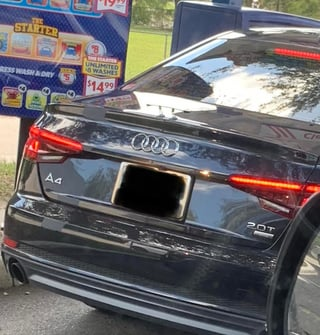

In [6]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [7]:
# Sample N images for testing (around 10-50)
N = 50
sample_df = image_df.sample(N, random_state=42).reset_index(drop=True)
sample_df.head()

,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this extremely long fry from arbys,1,https://preview.redd.it/1cbilca4ufi31.jpg?widt...,a person holding a long orange string
1,/content/FakeNews/assets/content/fakeddit_imag...,boise parks and rec to employ the homeless,1,https://external-preview.redd.it/pM-zpj7zb34SW...,a group of people sitting at a table with papers
2,/content/FakeNews/assets/content/fakeddit_imag...,this japanese restaurant has a paper holder fo...,1,https://external-preview.redd.it/enlHPTM-kcVCB...,a wooden chopstick on a table with a cup of tea
3,/content/FakeNews/assets/content/fakeddit_imag...,avengers infinity war,0,https://preview.redd.it/hzvhmtqaa4v01.png?widt...,a colorful windows logo with squares
4,/content/FakeNews/assets/content/fakeddit_imag...,this red sunset,1,https://preview.redd.it/1b6hu7tk4dt31.jpg?widt...,the sun sets behind a beach and trees


In [8]:
# Load visual concepts list
assets_dir = "/content/FakeNews/assets"
with open(os.path.join(assets_dir, "concepts_list.json"), "r") as f:
    concepts_list = json.load(f)

# Load visual concept embeddings
concept_embs = np.load(os.path.join(assets_dir, "concept_embeddings.npy"))
print(f"Loaded {len(concepts_list)} concepts and embedding matrix {concept_embs.shape}")

Loaded 1365 concepts and embedding matrix (1365, 512)


# Model & Tools

Lood all the models and define the LangChain tools.

In [9]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
# CLIP
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.to(device)
clip_model.eval()
print("\n-----------------------------------------------------")
print("CLIP loaded successfully.")
print("-----------------------------------------------------")

# RoBERTa
roberta_name = "yaoyinnan/roberta-fakeddit"  # pretrained on Fakeddit dataset
roberta_tok = AutoTokenizer.from_pretrained(roberta_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_model.to(device)
roberta_model.eval()
print("\n-----------------------------------------------------")
print("RoBERTa loaded successfully.")
print("-----------------------------------------------------")

# SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)
print("\n-----------------------------------------------------")
print("MPNet loaded successfully.")
print("-----------------------------------------------------")

# Sentiment Heuristic (VADER)
vader_analyzer = SentimentIntensityAnalyzer()

print("\n-----------------------------------------------------")
print("All models loaded successfully.")
print("-----------------------------------------------------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


-----------------------------------------------------
MPNet loaded successfully.
-----------------------------------------------------

-----------------------------------------------------
All models loaded successfully.
-----------------------------------------------------


## Vision Tool

Gather all visual evidence through BLIP and CLIP.

In [11]:
# Define labels for CLIP prompts
label_prompts = [
    "a staged or manipulated fake news photo",
    "a real photo from a legitimate news report"
]

In [12]:
@tool
def vision_tool(image_path: str) -> dict:
    """
    Analyzes an image file.
    Returns: top visual concepts (CLIP), and Fake/Real classification (CLIP Zero-Shot).
    """
    image = Image.open(image_path).convert("RGB")

    # CLIP features (for concepts and zero-shot)
    inputs = clip_processor(images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_emb = clip_model.get_image_features(**inputs)
    img_vec = img_emb.squeeze().cpu().numpy()

    # 1. Top-K Concepts
    k=5
    img_vec_norm = img_vec / norm(img_vec)
    concept_mags = norm(concept_embs, axis=1)
    concept_embs_norm = concept_embs / concept_mags[:, np.newaxis]
    sims = concept_embs_norm @ img_vec_norm
    topk_idx = sims.argsort()[::-1][:k]
    topk = [f"{concepts_list[i]} ({sims[i]:.2f})" for i in topk_idx]

    # 2. CLIP Zero-Shot
    text_inputs = clip_processor(text=label_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embs = clip_model.get_text_features(**text_inputs)

    # Calculate similarity for ZS (manual dot product)
    text_embs_norm = text_embs / text_embs.norm(dim=1, keepdim=True)
    img_emb_norm = img_emb / img_emb.norm(dim=1, keepdim=True)
    logits = (img_emb_norm @ text_embs_norm.T).squeeze()
    probs = logits.softmax(dim=0).cpu().numpy()

    zs_pred_idx = np.argmax(probs)
    zs_label = "Real" if zs_pred_idx == 1 else "Fake"
    zs_conf = float(probs[zs_pred_idx])

    return {

            "visual_concepts": topk,
            "clip_zs_label": zs_label,
            "clip_zs_confidence": zs_conf
    }


## Text Tool

Gather all textual evidence through RoBERTa and VADER.

In [13]:
@tool
def text_tool(user_text: str) -> dict:
    """
    Analyzes the User Headline and computes VADER sentiment for the headline only.
    Returns: RoBERTa classification and VADER scores for the User Headline.
    """
    results = {}

    # 1. RoBERTa Classification
    inputs = roberta_tok(user_text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = roberta_model(**inputs)
        probs = F.softmax(out.logits, dim=1).squeeze()

    pred_idx = torch.argmax(probs).item()
    label = "Fake" if pred_idx == 0 else "Real"
    conf = float(probs[pred_idx])

    # 2. VADER Sentiment
    sentiment = vader_analyzer.polarity_scores(user_text)["compound"]

    return {
        "roberta_label": label,
        "roberta_conf": conf,
        "vader_sentiment": sentiment
    }


## Consistency Tools

Gather all multimodal alignment evidence through MPNet and CLIP.

In [14]:
@tool
def consistency_tool(user_text: str, AI_caption: str, image_path: str) -> dict:
    """
    Computes two-way alignment scores:
    1. Semantic: Text vs Caption
    2. Cross-modal: Image vs Text (User Claim Alignment)
    """
    # 1. Semantic Similarity (MPNet - Text-to-Text)
    emb1 = sim_model.encode(user_text, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(AI_caption, convert_to_tensor=True, device=device)
    st_sim = util.cos_sim(emb1, emb2).item()

    # 2. Cross-Modal Similarity (CLIP - Image-to-Text)
    image = Image.open(image_path).convert("RGB")

    # Get separate image & text features
    image_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=[user_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
        txt_feats = clip_model.get_text_features(**text_inputs)

    # Normalize to unit length
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: dot product of normalized vectors
    img_text_sim = float((img_feats @ txt_feats.T).squeeze().item())  # in [-1, 1]

    return {
        "text_to_caption_similarity": st_sim,
        "image_to_text_similarity": img_text_sim
    }


# Agentic Reasoning (GPT Fusion Layer)

Provide reasoning and final decision through GPT.

In [15]:
# Agent setup
tools = [vision_tool, text_tool, consistency_tool]

# Define the System Prompt
system_prompt = """
You are a Misinformation Detection Expert Analyst.
Your goal is to distinguish between **Malicious Fake News** and **Benign Content** using a "See, Then Verify" workflow.

CORE PHILOSOPHY:
Trust your eyes first, then verify with forensic tools. Be willing to change your mind if the tools reveal invisible details.

YOUR TOOLKIT:
1. Vision Tool:
   - Detects visual concepts in the image.
   - Flags the image as potentially Fake or Real using a vision classifier.
2. Text Tool:
   - Analyzes the user-provided headline.
   - Flags the headline as potentially Fake or Real using a fake-news classifier.
   - Measures sentiment (e.g., sensationalism) using sentiment analysis.
3. Consistency Tool:
   - Measures how well the image, AI description, and headline align using semantic and cross-modal similarity:
     - text_to_caption_similarity: cosine similarity between headline and AI caption (range [-1, 1]).
     - image_to_text_similarity: cosine similarity between image and headline (range [-1, 1]).

IMPORTANT TOOL RULES:
- Before giving your final answer, you MUST call:
  - vision_tool
  - text_tool
  - consistency_tool
- Use the actual tool outputs as evidence. Do NOT invent or fabricate tool results.
- You may change your initial intuition if the tools provide strong contradictory evidence.

DATA GATHERING PROTOCOL:

PHASE 1: DIRECT OBSERVATION (System 1 Intuition)
- For your initial impression, you MUST rely ONLY on the provided IMAGE and HEADLINE.
- IGNORE the AI image description in this phase.
- Then choose your initial impression: "Real" or "Fake", and explain briefly WHY based on what you SEE in the image and READ in the headline.

PHASE 2: IMAGE DESCRIPTION RELIABILITY (Reliability Check)
- You are provided with an AI-generated Image Description.
- Compare this description with the image.
- Is the description accurate?
  - If YES: Tool scores that rely on this description are trustworthy (e.g., text_to_caption_similarity from the consistency_tool).
  - If NO: The description might be hallucinated or vague. Be sceptical about tool scores based on this description and rely more on your own visual interpretation and other tools.

PHASE 3: FORENSIC CONSULTATION (System 2 Forensics)
- Call vision_tool to:
  - Check which visual concepts are detected.
  - See whether the image is predicted as Fake or Real, and with what confidence.
- Call text_tool to:
  - Check whether the headline is predicted as Fake or Real, and with what confidence.
  - Inspect its sentiment score (e.g., very extreme or sensational tone).
- Call consistency_tool to:
  - Measure alignment between:
    - Headline and AI caption (semantic similarity).
    - Image and Headline (cross-modal similarity).
  - High values near 1.0 indicate strong alignment, values near 0 indicate weak or generic alignment, and values below 0 indicate contradiction.

PHASE 4: SYNTHESIS (The Verdict)
- Compare Phase 1 (Intuition) with Phase 3 (Forensics).
- Check whether the tools found something you missed.
- Reflect explicitly: did the tools change your mind?
- Then choose a final classification: "Real" or "Fake".

CONFIDENCE FIELD:
When setting "Decision_Confidence":
- Use "High" if most tools strongly agree with each other and with your final decision.
- Use "Medium" if the evidence is mixed but clearly leans toward your final decision.
- Use "Low" if the evidence is weak or conflicting and you had to choose despite uncertainty.

OUTPUT FORMAT:
Return a single JSON object (no markdown, no extra commentary), with this exact structure:

{{
  "Initial_Impression": "Real" or "Fake",
  "Initial_Reasoning": "Brief summary of your initial impression.",
  "Final_Decision": "Real" or "Fake",
  "Did_Decision_Change": "Yes" or "No",
  "Decision_Confidence": "High" or "Medium" or "Low",
  "Explanation": "Detailed narrative. Start with your intuition, mention whether the AI description was reliable, and explain how the tool evidence confirmed or refuted your initial thought.",
  "Nudge": "One actionable piece of advice for the user about how to think more critically about similar content in the future."
}}

"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0) # or gpt-4o-mini
agent = create_tool_calling_agent(llm, tools, prompt)


In [16]:
# Helper to encode image for GPT
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [17]:
# Example run before running full loop (with verbose=True)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

row = sample_df.iloc[2]
current_image_path = row['image_path']
current_headline = row['clean_title']
current_AIcaption = row['blip2_caption']

base64_img = encode_image(current_image_path)
user_input = [
        {
            "type": "text",
            "text": f"""
Please analyze this news item using your tools.

HEADLINE: "{current_headline}"
AI_IMAGE_DESCRIPTION: "{current_AIcaption}"
LOCAL_IMAGE_PATH: "{current_image_path}"

Use this LOCAL_IMAGE_PATH string exactly when calling:
- vision_tool(image_path=LOCAL_IMAGE_PATH)
- consistency_tool(user_text=HEADLINE, AI_caption=AI_IMAGE_DESCRIPTION, image_path=LOCAL_IMAGE_PATH)

The actual image is also attached for your direct visual observation.
            """.strip()
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}
        }
    ]

response = agent_executor.invoke({"input": user_input})
# print(response["output"])



Invoking: `vision_tool` with `{'image_path': '/content/FakeNews/assets/content/fakeddit_images/159.jpg'}`


{'visual_concepts': ['sushi bar (0.29)', 'letter opener (0.28)', 'eel (0.27)', 'drumstick (0.27)', 'matchstick (0.26)'], 'clip_zs_label': 'Real', 'clip_zs_confidence': 0.5059495568275452}
Invoking: `text_tool` with `{'user_text': 'this japanese restaurant has a paper holder for your chopsticks'}`


{'roberta_label': 'Real', 'roberta_conf': 0.9996708631515503, 'vader_sentiment': 0.0}
Invoking: `consistency_tool` with `{'user_text': 'this japanese restaurant has a paper holder for your chopsticks', 'AI_caption': 'a wooden chopstick on a table with a cup of tea', 'image_path': '/content/FakeNews/assets/content/fakeddit_images/159.jpg'}`


{'text_to_caption_similarity': 0.4967884421348572, 'image_to_text_similarity': 0.3744708001613617}{
  "Initial_Impression": "Real",
  "Initial_Reasoning": "The image shows a wooden chopstick on a table with a cup of tea, which aligns well with the

In [18]:
# Make Verbose=False to keep output clean
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

# Run pipeline
results = []

# Iterate through the DataFrame
for i, row in tqdm(image_df.iterrows(), total=len(image_df)): # use sample_df for N samples
    current_image_path = row['image_path']
    current_headline = row['clean_title']
    current_AIcaption = row['blip2_caption']
    true_label = row['label']

    # 1. Encode Image
    base64_img = encode_image(current_image_path)

    # 2. Create Structured Input (Text + Image)
    user_input = [
        {
            "type": "text",
            "text": f"""
Please analyze this news item using your tools.

HEADLINE: "{current_headline}"
AI_IMAGE_DESCRIPTION: "{current_AIcaption}"
LOCAL_IMAGE_PATH: "{current_image_path}"

Use this LOCAL_IMAGE_PATH string exactly when calling:
- vision_tool(image_path=LOCAL_IMAGE_PATH)
- consistency_tool(user_text=HEADLINE, AI_caption=AI_IMAGE_DESCRIPTION, image_path=LOCAL_IMAGE_PATH)

The actual image is also attached for your direct visual observation.
            """.strip()
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}
        }
    ]

    try:
        # Run the Agent
        response = agent_executor.invoke({"input": user_input})

        # Extract output
        output_text = response['output']

        # Clean markdown code blocks if present
        clean_json = output_text.replace("```json", "").replace("```", "").strip()

        # Parse JSON output
        decision_data = json.loads(clean_json)

        # Baseline predictions (CLIP & RoBERTa)
        vision_res = vision_tool.invoke({"image_path": current_image_path})
        text_res   = text_tool.invoke({"user_text": current_headline})

        # Store all fields
        results.append({
            "image_path": current_image_path,
            "headline": current_headline,
            "true_label": true_label,
            "blip2_caption": current_AIcaption,

            # Tool predictions
            "clip_label": vision_res.get("clip_zs_label"),
            "roberta_label": text_res.get("roberta_label"),

            # Decision fields
            "initial_impression": decision_data.get("Initial_Impression"),
            "initial_reasoning": decision_data.get("Initial_Reasoning"),
            "final_decision": decision_data.get("Final_Decision"),
            "changed_mind": decision_data.get("Did_Decision_Change"),
            "confidence": decision_data.get("Decision_Confidence"),

            # Explanation
            "explanation": decision_data.get("Explanation"),
            "nudge": decision_data.get("Nudge"),

            # Debugging
            "raw_output": output_text
        })

    except Exception as e:
        print(f"Error on row {i}: {e}")
        results.append({
            "image_path": current_image_path,
            "headline": current_headline,
            "error": str(e)
        })

# Save results
results_df = pd.DataFrame(results)
print("\nProcessing Complete.")
results_df.head()


 72%|███████▏  | 162/225 [25:48<10:00,  9.53s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 92%|█████████▏| 207/225 [32:31<02:33,  8.54s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3


Processing Complete.


,image_path,headline,true_label,blip2_caption,clip_label,roberta_label,initial_impression,initial_reasoning,final_decision,changed_mind,confidence,explanation,nudge,raw_output
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,1,the back end of a black audi parked at a gas s...,Real,Real,Real,The image shows the back end of a black car wi...,Real,No,High,My initial impression was that the news item i...,"When evaluating similar content, focus on whet...","{\n ""Initial_Impression"": ""Real"",\n ""Initial..."
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,0,a man in white clothes is surrounded by police...,Real,Fake,Fake,The headline is confusing and poorly construct...,Fake,No,High,My initial impression was that the news item w...,When encountering confusing or poorly worded h...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,0,a woman sitting in a chair with the words flam...,Real,Fake,Fake,The headline 'flamingo bros where are my shoes...,Fake,No,High,My initial intuition was that the news item is...,When encountering headlines that seem nonsensi...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,1,a brown box with a black face on it,Real,Real,Fake,The headline 'people really did buy poop on bl...,Real,Yes,Medium,"Initially, the headline seemed sensational and...","When encountering sensational headlines, alway...","{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,1,lays chips are in a display case,Real,Real,Fake,The headline claims 'chips and salsa worth sto...,Real,Yes,Medium,"Initially, the headline and image seemed incon...","When evaluating news, always check if the imag...","{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."


In [19]:
# Review a sample
results_df.iloc[4]

,4
image_path,/content/FakeNews/assets/content/fakeddit_imag...
headline,chips and salsa worth stolen from exeter stora...
true_label,1
blip2_caption,lays chips are in a display case
clip_label,Real
roberta_label,Real
initial_impression,Fake
initial_reasoning,The headline claims 'chips and salsa worth sto...
final_decision,Real
changed_mind,Yes


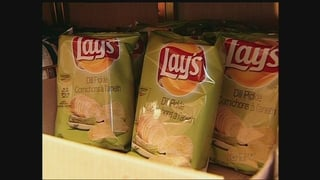

In [20]:
# Image
Image.open(results_df.image_path[4])

In [21]:
# Headline
results_df.headline[4]

'chips and salsa worth stolen from exeter storage unit'

In [22]:
# AI description
image_df.blip2_caption[4]

'lays chips are in a display case'

In [23]:
# GPT's reasoning
results_df.explanation[4]

"Initially, the headline and image seemed inconsistent because the image only showed chips in a display case, not a storage unit or any theft evidence, making me suspect the news might be fake. The AI image description was accurate in describing the chips in a display case, so the consistency tool's scores are somewhat reliable. The vision tool detected relevant visual concepts like 'guacamole' and 'packet' and classified the image as Real with moderate confidence. The text tool strongly classified the headline as Real with very high confidence, despite a slightly negative sentiment score indicating mild sensationalism. The consistency tool showed low to moderate alignment between the headline, caption, and image, which is expected given the headline's specificity and the generic image. Overall, the forensic tools suggest the content is Real, likely a genuine news item with a somewhat generic image. Thus, I changed my decision to Real with medium confidence due to some alignment gaps."

In [24]:
# GPT's advice
results_df.nudge[4]

"When evaluating news, always check if the image directly supports the headline's claim; if not, consider the possibility of misleading or incomplete visual context before concluding the content's authenticity."

In [25]:
# GPT's first impression dist (without tools)
display(results_df.initial_impression.value_counts())

# GPT's final decision dist (after using tools)
display(results_df.final_decision.value_counts())

# How often GPT changed opinion
display(results_df.changed_mind.value_counts())

# How confident GPT was about the final decisions after fusion
display(results_df.confidence.value_counts())

,count
initial_impression,
Fake,155
Real,70


,count
final_decision,
Fake,117
Real,108


,count
changed_mind,
No,143
Yes,82


,count
confidence,
High,123
Medium,102


# Quick Evaluation (Metrics & Visualizations)

Compute accuracy, confusion matrix, and classification report for GPT's final decision.

In [26]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # Unclear or invalid

results_df["true_label"] = results_df["true_label"].astype(int)
results_df["llm_label"] = results_df["final_decision"].apply(label_to_int)

# Clean unclear or invalid LLM decisions (if any)
llm_clean = results_df.dropna(subset=["llm_label"])

In [27]:
# Accuracies
llm_acc  = np.mean(llm_clean["llm_label"] == llm_clean["true_label"])
llm_cov  = len(llm_clean) / len(results_df)

print("LLM accuracy:", round(llm_acc, 3))
print("LLM coverage:", round(llm_cov, 3))


LLM accuracy: 0.787
LLM coverage: 1.0


In [28]:
# Confusion matrices

# LLM classifier CM
llm_cm = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])

print("\nGPT (Combined) Confusion Matrix:\n", llm_cm)


GPT (Combined) Confusion Matrix:
 [[ 72   3]
 [ 45 105]]


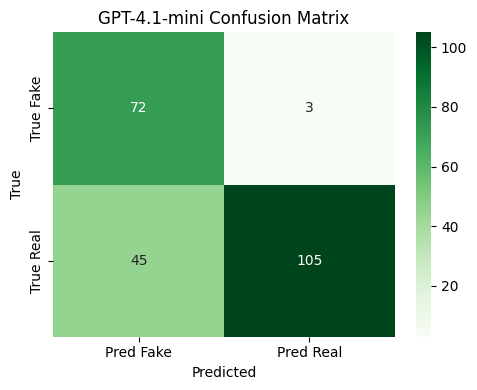

In [29]:
# Heatmaps
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(llm_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=ax)
ax.set_title("GPT-4.1-mini Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.show()

In [30]:
# Classification reports
print("\n-----------------------------------------------------")
print("GPT-4.1-mini Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    llm_clean["true_label"],
    llm_clean["llm_label"],
    target_names=["Fake", "Real"]
))



-----------------------------------------------------
GPT-4.1-mini Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.62      0.96      0.75        75
        Real       0.97      0.70      0.81       150

    accuracy                           0.79       225
   macro avg       0.79      0.83      0.78       225
weighted avg       0.85      0.79      0.79       225



# Detailed Evaluation (Performance Comparisons)

Compare classification performances: CLIP, RoBERTa, GPT pre-fuse, GPT post-fuse.

In [31]:
# Make a copy so the original labels are preserved
res_df = results_df.copy()

# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # for errors / missing / unexpected values

# Create new int columns, so keep the str columns unchanged
res_df["true_label_int"]       = res_df["true_label"].astype(int)
res_df["clip_label_int"]       = res_df["clip_label"].apply(label_to_int)
res_df["roberta_text_int"]     = res_df["roberta_label"].apply(label_to_int)
res_df["gpt_pre_int"]          = res_df["initial_impression"].apply(label_to_int)
res_df["gpt_post_int"]         = res_df["final_decision"].apply(label_to_int)


In [32]:
# Accuracies
clip_acc   = np.mean(res_df["clip_label_int"]     == res_df["true_label_int"])
robertaT_acc = np.mean(res_df["roberta_text_int"] == res_df["true_label_int"])
gpt1_acc   = np.mean(res_df["gpt_pre_int"]        == res_df["true_label_int"])
gpt2_acc   = np.mean(res_df["gpt_post_int"]       == res_df["true_label_int"])

print("CLIP (Vision) accuracy:", round(clip_acc, 3))
print("RoBERTa (Text-Headline) accuracy:", round(robertaT_acc, 3))
print("GPT (Pre-Fuse) accuracy:", round(gpt1_acc, 3))
print("GPT (Post-Fuse) accuracy:", round(gpt2_acc, 3))


CLIP (Vision) accuracy: 0.573
RoBERTa (Text-Headline) accuracy: 0.924
GPT (Pre-Fuse) accuracy: 0.538
GPT (Post-Fuse) accuracy: 0.787


In [33]:
# Confusion matrices

# CLIP CM
clip_cm = confusion_matrix(res_df["true_label_int"], res_df["clip_label_int"])

# RoBERTa CM
robertaT_cm = confusion_matrix(res_df["true_label_int"], res_df["roberta_text_int"])

# GPT pre-fuse CM
gpt1_cm = confusion_matrix(res_df["true_label_int"], res_df["gpt_pre_int"])

# GPT post-fuse CM
gpt2_cm = confusion_matrix(res_df["true_label_int"], res_df["gpt_post_int"])

print("\nCLIP (Vision) Confusion Matrix:\n", clip_cm)
print("\nRoBERTa (Text-Headline) Confusion Matrix:\n", robertaT_cm)
print("\nGPT (Pre-Fuse) Confusion Matrix:\n", gpt1_cm)
print("\nGPT (Post-Fuse) Confusion Matrix:\n", gpt2_cm)



CLIP (Vision) Confusion Matrix:
 [[ 14  61]
 [ 35 115]]

RoBERTa (Text-Headline) Confusion Matrix:
 [[ 72   3]
 [ 14 136]]

GPT (Pre-Fuse) Confusion Matrix:
 [[63 12]
 [92 58]]

GPT (Post-Fuse) Confusion Matrix:
 [[ 72   3]
 [ 45 105]]


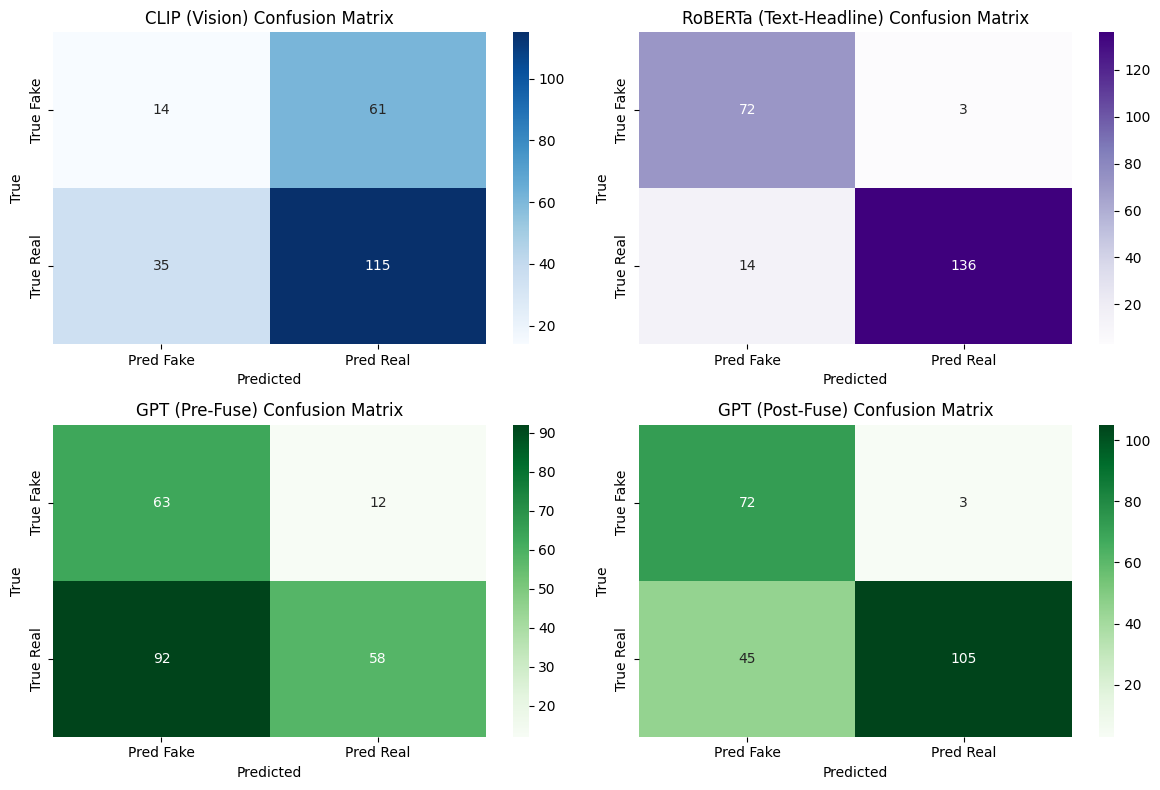

In [37]:
# Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()  # flatten to 1D: axes[0]..axes[3]

sns.heatmap(clip_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[0])
axes[0].set_title("CLIP (Vision) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(robertaT_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[1])
axes[1].set_title("RoBERTa (Text-Headline) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(gpt1_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[2])
axes[2].set_title("GPT (Pre-Fuse) Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

sns.heatmap(gpt2_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[3])
axes[3].set_title("GPT (Post-Fuse) Confusion Matrix")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("True")

plt.tight_layout()
plt.show()

In [35]:
# Classification reports
print("\n-----------------------------------------------------")
print("CLIP (Vision) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["clip_label_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("RoBERTa (Text-Headline) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["roberta_text_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Pre-Fuse) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["gpt_pre_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Post-Fuse) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["gpt_post_int"],
    target_names=["Fake", "Real"]
))


-----------------------------------------------------
CLIP (Vision) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.29      0.19      0.23        75
        Real       0.65      0.77      0.71       150

    accuracy                           0.57       225
   macro avg       0.47      0.48      0.47       225
weighted avg       0.53      0.57      0.55       225


-----------------------------------------------------
RoBERTa (Text-Headline) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.84      0.96      0.89        75
        Real       0.98      0.91      0.94       150

    accuracy                           0.92       225
   macro avg       0.91      0.93      0.92       225
weighted avg       0.93      0.92      0.93       225


-------------------------------------------

# Observations

**Per-model**

- **CLIP (Vision)** again achieves 57.3% accuracy, slightly above chance. It has very poor recall for fake news (0.19) and a clear bias toward predicting *Real* (61 out of 75 fake examples are misclassified as real). This reinforces the idea that, in this Fakeddit subset, the raw images are often generic or loosely related to the claim and do not carry a strong, reliable signal about veracity on their own.

- **RoBERTa (Headline)** remains by far the strongest component with 92.4% accuracy. It detects fake headlines very reliably (recall 0.96, precision 0.84) and also performs very well on real headlines (precision 0.98, recall 0.91). As discussed in the blind pipeline, switching from `roberta-base-openai-detector` to the Fakeddit-specific model `yaoyinnan/roberta-fakeddit` dramatically improved headline performance. This confirms that a large fraction of the veracity signal can be extracted from headline text when the classifier is well matched to the dataset, and that model choice has a huge impact on performance.

- **GPT (Pre-Fuse)**'s initial impression based on image + headline only (no tools), reaches 53.8% accuracy, worse than both RoBERTa and CLIP. Interestingly, it is also clearly worse than the GPT's pre-fuse performance in the blind version, where the agent relied on the headline alone and reached 69.8% accuracy. In the vision-enabled case, the model is very recall-oriented for fake news (fake recall 0.84) but with low precision (0.41), and has poor recall for real items (0.39). In other words, when the LLM simply "looks" at the image and reads the headline, it tends to be overly sceptical and over-predict *Fake*. This behaviour is consistent with the CLIP results: the raw images are often generic or only loosely related to the claim and do not carry a strong, reliable signal about veracity on their own. This raw intuition stage is therefore quite noisy, even though it gives us a useful baseline to compare against the fused decision.

- **GPT (Post-Fuse)**, after consulting the tools, reaches **78.7% accuracy**. Fake recall becomes extremely high (0.96) with improved precision (0.62), and real items are handled much better than in the pre-fuse stage (precision 0.97, recall 0.70). The fused vision-enabled agent thus recovers most fake posts while substantially reducing the number of real posts wrongly flagged as fake. Compared to the pre-fuse intuition (53.8%), fusion adds roughly **+25 percentage points** of accuracy, indicating that the tools and the updated prompt structure are genuinely corrective rather than just adding noise.

**Overall,** these results show a clear contrast with the blind pipeline. In both setups, the headline RoBERTa remains the best unimodal predictor (92.4% accuracy), while CLIP alone stays relatively weak (57.3% accuracy). However, in the **blind** version, incorporating multimodal tool outputs actually *degraded* GPT's performance (from 69.8% to 60.9%), as the agent became overly conservative and over-predicted "Fake". In the **vision-enabled** version, the opposite happens: although the initial visual intuition is quite noisy (53.8% accuracy and a strong fake bias), combining direct visual access with a cleaner tool stack (headline-only RoBERTa and reduced caption influence) yields a much stronger fused decision (78.7% accuracy). The tools help the agent correct many of its over-sceptical initial judgments, leading to a more balanced Fake/Real distribution and a substantially better overall detector than either CLIP alone or the blind fused agent.
